## Subtração do fundo na curva de luz

In [5]:
import sys
import os
from pathlib import Path

sys.path.append('/home/maju/projeto/LS5039/src') 
from processamento import subtrair_fundo, calcular_fase_orbital

# Parâmetros 
ano = "2022"
binagem = "b1s"
energia = "10_30kev" 
obsid = "30701024002A01" 

raios = {
    '2022': {'src': 18.984525, 'bkg': 38.948665},
    '2017': {'src': 20.500000, 'bkg': 40.000000}
}

project_root = Path("/home/maju/projeto/LS5039")

arq_fonte = project_root / f"/home/maju/projeto/LS5039/data/raw/light_curves/2022/nu30701024002A01_2022_b1s_10_30_sr.lc"
arq_fundo = project_root / f"/home/maju/projeto/LS5039/data/raw/light_curves/2022/nu30701024002A01_2022_b1s_10_30_bk.lc"
arq_saida = project_root / f"/home/maju/projeto/LS5039/data/processed/sub_2022_b1s_10_30kev.lc"

os.makedirs(project_root / "data/processed", exist_ok=True)

subtrair_fundo(str(arq_fonte), str(arq_fundo), raios[ano]['src'], raios[ano]['bkg'], str(arq_saida))
print("Processamento concluído!")

Fator de escala de área (a) calculado: 0.2376
Sucesso! Ficheiro corrigido salvo em: /home/maju/projeto/LS5039/data/processed/sub_2022_b1s_10_30kev.lc

Processamento concluído!


### Curva de luz interativa

Aplicando zoom podemos verificar os instantes nos quais o satélite orbita o planeta e ocorre perda de dados, isso adiciona viés na busca por modulações no periodograma e deverá ser retirado nas próximas análises.

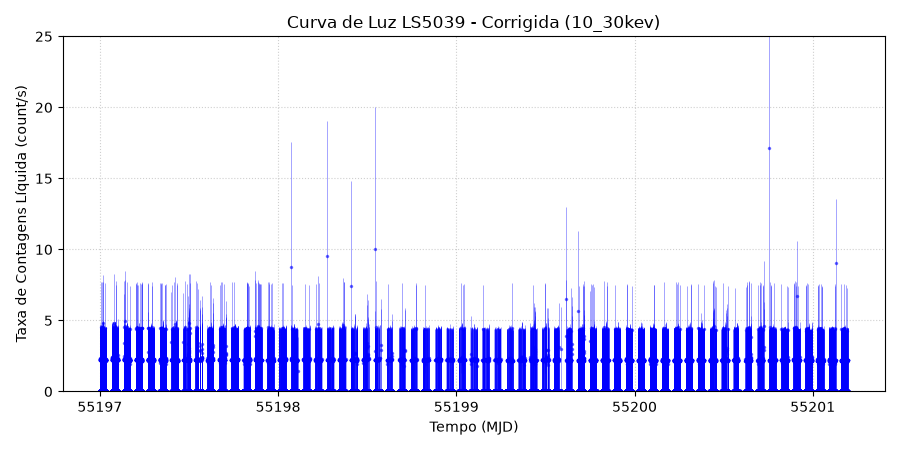

In [7]:
%matplotlib widget

import matplotlib.pyplot as plt
from astropy.table import Table

tabela = Table.read(arq_saida, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.errorbar(df['MJD'], df['RATE'], yerr=df['ERROR'], fmt='b.', alpha=0.5, markersize=3, elinewidth=0.5)

plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens Líquida (count/s)')
plt.title(f'Curva de Luz LS5039 - Corrigida ({energia})')
plt.grid(True, ls=':', alpha=0.6)
plt.ylim(0,25)

plt.tight_layout()
plt.show()

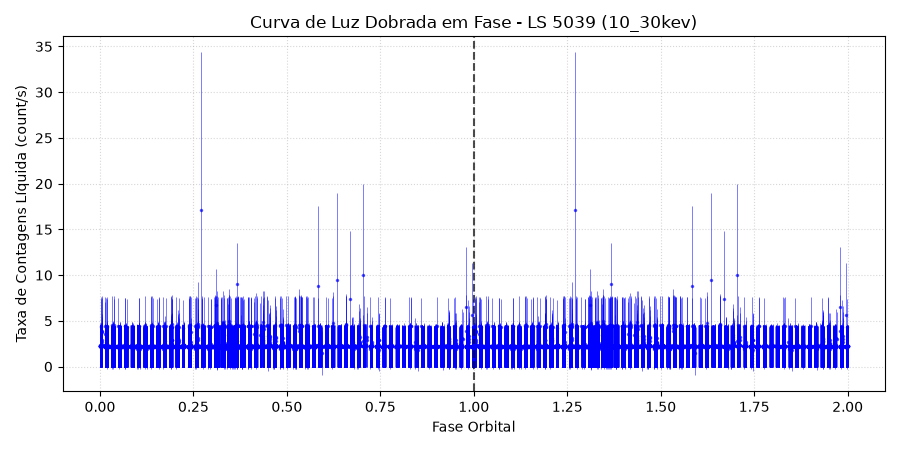

In [8]:
from astropy.table import Table
import matplotlib.pyplot as plt

tabela = Table.read(str(arq_saida), hdu=1)
df_completo = calcular_fase_orbital(tabela)

plt.figure(figsize=(9, 4.5))
plt.errorbar(df_completo['FASE'], df_completo['RATE'], yerr=df_completo['ERROR'], 
             fmt='b.', alpha=0.6, markersize=3, elinewidth=0.6)

plt.axvline(1.0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens Líquida (count/s)')
plt.title(f'Curva de Luz Dobrada em Fase - LS 5039 ({energia})')
plt.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()